In [13]:
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
from pathlib import Path
import os, sys, json, inspect, hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Code

candidatos=[]
for base in [Path.cwd(), *Path.cwd().parents]:
    candidatos += [base, base/'classificador_features_sms']
PROJETO=next(p for p in candidatos if (p/'notebook_features_final/configuracao_emocao.json').exists())
sys.path.insert(0,str(PROJETO.parent))
PASTA=PROJETO/'notebook_features_final'; SAIDA=PASTA/'resultados'
if Path('/tmp/sms-features-lt/LanguageTool-6.8').exists():
    os.environ.setdefault('LTP_PATH','/tmp/sms-features-lt')
from classificador_features_sms.notebook_features_final import classificador as motor
from classificador_features_sms.notebook_features_final.executar import executar, digest, validar_revisoes
from classificador_features_sms.notebook_features_final.features import carga_emocional
pd.set_option('display.max_colwidth',110)
plt.rcParams.update({'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
fonte=PROJETO/'dataset_estaticos/DATASET - Dataset_limpo_V1.csv'
hash_fonte=digest(fonte)
assert digest(PASTA/'testes/sms_teste.csv')==json.loads((PASTA/'testes/gabarito_proveniencia.json').read_text())['sha256_csv']
print('Referência:',fonte.name)
print('Saídas novas:',SAIDA.name)

Referência: DATASET - Dataset_limpo_V1.csv
Saídas novas: resultados


## 2. Revisão das 24 features

A revisão considera definição, condição positiva, exclusões e ambiguidade. Os scripts que já implementavam o critério central foram preservados. Mudanças no motor comum também beneficiam esses scripts: pedidos polidos, negação local, diferenciação do substantivo telefone e proteção contra palavras contidas em URLs.

O relatório detalhado está em [REVISAO_DAS_FEATURES.md](REVISAO_DAS_FEATURES.md). As páginas indicadas são as páginas físicas do [PDF fornecido](fontes/Dicionario_de_Features.pdf).

As regras não compreendem toda a linguagem natural. Discurso citado, ironia, elipses e dependências longas ainda podem falhar. “Não detectado” é uma saída do método, não prova de ausência. Preservar um script indica que não encontramos motivo específico para alterá-lo nos critérios e testes examinados; não certifica perfeição.

In [15]:
revisao_features=pd.read_json(PASTA/'revisao_das_features.json')
display(revisao_features[['feature','pagina_pdf','decisao','revisao']])

,feature,pagina_pdf,decisao,revisao
0,solicita_senha,2,arquivo específico preservado,Regra específica mantida: a condição central e as exclusões examinadas correspondem ao dicionário; continu...
1,solicita_codigo_autenticacao,3,ajustado,Acrescenta pedidos de código recebido/enviado por SMS ou WhatsApp; conserva exclusão de códigos de produto...
2,solicita_dados_bancarios,4,arquivo específico preservado,Regra específica mantida: a condição central e as exclusões examinadas correspondem ao dicionário; continu...
3,solicita_dados_pessoais,5,arquivo específico preservado,Regra específica mantida: a condição central e as exclusões examinadas correspondem ao dicionário; continu...
4,solicita_dados_cartao,6,arquivo específico preservado,Regra específica mantida: a condição central e as exclusões examinadas correspondem ao dicionário; continu...
5,solicita_atualizacao_cadastro,7,arquivo específico preservado,Regra específica mantida: a condição central e as exclusões examinadas correspondem ao dicionário; continu...
6,solicita_pagamento,8,arquivo específico preservado,Regra específica mantida: a condição central e as exclusões examinadas correspondem ao dicionário; continu...
7,solicita_clique,9,arquivo específico preservado,Regra específica mantida: a condição central e as exclusões examinadas correspondem ao dicionário; continu...
8,solicita_ligacao,10,arquivo específico preservado,Regra específica mantida: a condição central e as exclusões examinadas correspondem ao dicionário; continu...
9,menciona_bloqueio_conta,11,arquivo específico preservado,Regra específica mantida: a condição central e as exclusões examinadas correspondem ao dicionário; continu...


### Bibliotecas utilizadas

- **re / unicodedata:** padrões de solicitação, alvo, condição e negação; normalização de caixa/acentos.
- **linkify-it-py + urllib.parse/ipaddress:** identificação de URLs e validação do host, sem visitar os endereços. Encurtadores continuam numa lista fixa.
- **phonenumbers:** validação do plano brasileiro e exclusão de números estrangeiros; máscaras reduzem confusão com CPF, CEP e códigos rotulados.
- **regex:** reconhecimento de PIX como palavra, com limites Unicode, fora de URLs.
- **language-tool-python / LanguageTool 6.8:** corretor local pt-BR. Usamos só ortografia/gramática, filtramos linguagem informal e correções apenas de acento/caixa, e mantemos alertas aceitos e ignorados. Regras manuais conhecidas complementam sua cobertura.
- **pandas / NumPy / Matplotlib:** leitura, comparação, contagens, calibração dos limites emocionais e gráficos.

Documentação: [linkify-it-py](https://linkify-it-py.readthedocs.io/en/latest/), [phonenumbers](https://github.com/daviddrysdale/python-phonenumbers), [language-tool-python](https://github.com/jxmorris12/language_tool_python).

A biblioteca não é escolhida só por ser especializada: o critério é implementar a definição de forma auditável. Para intenções, as regras explícitas evitam aprender associações potencialmente erradas dos rótulos originais.

## 3. Carga emocional: baixa, média e alta

A medida continua sendo **ocorrências emocionais / palavras analisáveis**, conforme o PDF. O léxico é fixo; URLs, e-mails e números são excluídos. As palavras emocionais repetidas contam novamente; stopwords entram no denominador. Sem palavras analisáveis, convencionamos proporção zero.

Como o PDF não fornece cortes, usamos uma regra reproduzível: **tercis das 114 proporções positivas** encontradas nos 1.347 textos de referência, sem consultar seus rótulos emocionais. Zeros ficam em baixa. O objetivo é dividir a intensidade lexical positiva relativa a este corpus, evitando que a grande quantidade de zeros produza três limites iguais.

- **Baixa:** proporção ≤ 1/17, aproximadamente 5,882%.
- **Média:** acima de 1/17 e ≤ 1/14, aproximadamente 7,143%.
- **Alta:** acima de 1/14.

Os limites foram congelados em `configuracao_emocao.json` e não mudam com cada lote. Empates ficam na categoria inferior. Continuamos exportando a proporção para que as faixas possam ser reavaliadas. Esses nomes são categorias operacionais relativas ao corpus, **não uma escala psicológica validada**, nem uma reconstrução dos critérios desconhecidos de Baixo/Médio/Alto no CSV original.

In [16]:
config=carga_emocional.configuracao()
display(pd.Series(config).to_frame('configuracao'))
display(Code(inspect.getsource(carga_emocional),language='python'))
assert carga_emocional.categorizar(config['limite_baixa'])=='baixa'
assert carga_emocional.categorizar(config['limite_media'])=='média'
assert carga_emocional.categorizar(config['limite_media']+1e-6)=='alta'

,configuracao
metodo,tercis das proporções estritamente positivas; zero na faixa baixa; empates na faixa inferior
limite_baixa,0.058824
limite_media,0.071429
n_referencia,1347
n_proporcoes_positivas,114
referencia_sha256,2defcaef52bdd3cbb95fadb43bf915e1950f95ca443e4c928ff7ad512fafed50
usa_rotulos_originais,False
recalcular_automaticamente,False
interpretacao,"faixas relativas ao corpus, não intensidade psicológica validada"


"""Proporção lexical preservada, agora com faixas baixa/média/alta congeladas.

Os limites são os tercis das proporções POSITIVAS da referência textual;
zeros ficam na faixa baixa. Nenhum rótulo Baixo/Médio/Alto treina as faixas.
Os limites são carregados de configuracao_emocao.json e nunca recalculados
por mensagem ou por lote. São relativos ao corpus, não escalas psicológicas.
"""
import json
import re
from pathlib import Path
from functools import lru_cache
from ..regras import normalizar
from ..bibliotecas._urls import mascarar_urls

LEXICO_EMOCIONAL = frozenset('medo perigo perigoso perigosa panico terror ameaca preocupacao preocupado preocupada ansiedade ansioso ansiosa triste tristeza raiva odio desespero desesperado desesperada alegria alegre feliz felicidade amor carinho esperanca surpresa surpreso vergonha culpa confianca parabens urgente urgencia alerta grave risco perder perda'.split())

@lru_cache(maxsize=1)
def configuracao():
    dados = json.loads((Path(__file__).parents[1]/'configuracao_emocao.json').read_text())
    if not 0 < dados['limite_baixa'] < dados['limite_media'] <= 1:
        raise ValueError('Limites emocionais inválidos.')
    return dados

def medir(sms):
    limpo = re.sub(r'\S+@\S+', ' ', mascarar_urls(sms))
    palavras = re.findall(r'\b[a-z]+\b', normalizar(limpo))
    emocionais = [p for p in palavras if p in LEXICO_EMOCIONAL]
    return {'palavras_analisaveis': len(palavras), 'palavras_emocionais': emocionais,
            'ocorrencias_emocionais': len(emocionais),
            'proporcao': len(emocionais)/len(palavras) if palavras else 0.0}

def categorizar(proporcao):
    if not 0 <= proporcao <= 1: raise ValueError('Proporção fora de 0 a 1.')
    c = configuracao()
    # Empates nos limites pertencem à faixa inferior, inclusive zero.
    return 'baixa' if proporcao <= c['limite_baixa'] else 'média' if proporcao <= c['limite_media'] else 'alta'

def classificar(sms):
    return categorizar(medir(sms)['proporcao'])

## 4. Executar a versão revisada

O script classifica as mesmas mensagens da referência, mantendo texto e `possivel_golpe`. Compara cada feature e guarda toda discordância, sem escolher automaticamente o vencedor. Categorias masculinas/femininas do original são normalizadas apenas para comparar (`Baixo` → `baixa`, etc.).

Também executa o CSV sintético separado. O gabarito foi escrito antes da primeira execução. Aquela rodada passou em 142/144 casos; corrigimos duas falhas de regra sem alterar o esperado. O resultado inicial está guardado em `resultados/testes_execucao_inicial.csv`. Portanto, os 144 casos são testes de desenvolvimento/regressão, não um conjunto cego independente.

Ao reexecutar, as decisões de `revisao_humana.csv` são preservadas por um ID que inclui mensagem, feature e par de valores. O arquivo anterior é arquivado antes da regeneração. Se esses valores mudarem, o caso recebe novo ID e precisa de nova revisão.

In [17]:
resumo,metricas,revisao,testes=executar()
assert digest(fonte)==hash_fonte
validar_revisoes(revisao)
display(pd.Series({k:resumo[k] for k in ['mensagens_originais','features','celulas_comparadas','divergencias','mensagens_com_divergencia','concordancia_percentual','sms_sinteticos','testes_alvo_concordantes','testes_alvo_divergentes']}).to_frame('resultado'))

Classificando 1347 mensagens originais, sem modificar a fonte.
LanguageTool: 250/1347 mensagens processadas.
LanguageTool: 500/1347 mensagens processadas.
LanguageTool: 750/1347 mensagens processadas.
LanguageTool: 1000/1347 mensagens processadas.
LanguageTool: 1250/1347 mensagens processadas.
Executando 144 SMS sintéticos separados.


,resultado
mensagens_originais,1347.000000
features,24.000000
celulas_comparadas,32328.000000
divergencias,4260.000000
mensagens_com_divergencia,1137.000000
concordancia_percentual,86.822569
sms_sinteticos,144.000000
testes_alvo_concordantes,144.000000
testes_alvo_divergentes,0.000000


## 5. Onde estão as diferenças

O arquivo principal é **revisao_humana.csv**: uma linha por mensagem/feature divergente, com os dois valores, definição, página do PDF, método e evidência. O ID é estável; `registro_original` começa em 1 para a primeira mensagem e não conta o cabeçalho. Não é um deslocamento físico de linha em arquivos com quebras dentro de campos.

Você pode registrar `original`, `gerado`, `outro` ou `inconclusivo` em `decisao_humana`; `outro` exige `valor_decidido`. Use `comentario_revisor` para a justificativa. Nenhuma decisão altera a fonte automaticamente.

No [painel de revisão](resultados/revisao_divergencias.html), as alterações ficam na página até você clicar em **Baixar revisão CSV**. Para continuar depois, importe o CSV baixado no painel. Para o notebook reaproveitar essas decisões, coloque o arquivo baixado no lugar de `resultados/revisao_humana.csv` antes de reexecutar.

A evidência semântica é um trecho que sozinho ativa a regra, quando encontrado, ou o contexto completo. Isso mostra o motivo operacional, não uma explicação causal de um modelo estatístico. Para ausência, registramos que o padrão não foi detectado. URLs, telefones, gramática e emoção apresentam evidências específicas.

In [18]:
# Troque os valores para investigar qualquer feature ou texto no notebook.
FEATURE_FILTRO='solicita_codigo_autenticacao'  # use '' para todas
TEXTO_FILTRO=''                             # trecho da mensagem, sem regex
filtro=revisao.copy()
if FEATURE_FILTRO: filtro=filtro[filtro.feature.eq(FEATURE_FILTRO)]
if TEXTO_FILTRO: filtro=filtro[filtro.Mensagem.str.contains(TEXTO_FILTRO,case=False,regex=False)]
print(f'{len(filtro)} divergências no filtro; mostrando até 8. Texto integral no CSV/painel.')
display(filtro[['registro_original','Mensagem','feature','valor_original','valor_gerado','evidencia_script']].head(8))

121 divergências no filtro; mostrando até 8. Texto integral no CSV/painel.


,registro_original,Mensagem,feature,valor_original,valor_gerado,evidencia_script
13,20,C?digo de login em Ativas Farma: 0564 @ativasfarma.com.br #0564,solicita_codigo_autenticacao,1,0,Nenhum padrão afirmativo previsto foi detectado; conferir cobertura e contexto.
14,81,"Use 326829 para validar seu telefone na OLX. Para proteger sua conta, nao compartilhe este codigo. Nao ped...",solicita_codigo_autenticacao,1,0,Nenhum padrão afirmativo previsto foi detectado; conferir cobertura e contexto.
15,82,"3m1Ew/Zt9XJAmazon: Your code is 499696. Don t share it. If you didn t request it, deny here https://amazon...",solicita_codigo_autenticacao,1,0,Nenhum padrão afirmativo previsto foi detectado; conferir cobertura e contexto.
16,83,"Amazon: Your code is 816874. Don t share it. If you didn t request it, deny here https://amazon.com/a/c/r/...",solicita_codigo_autenticacao,1,0,Nenhum padrão afirmativo previsto foi detectado; conferir cobertura e contexto.
17,84,G-106571 é seu código de verificação do Google.,solicita_codigo_autenticacao,1,0,Nenhum padrão afirmativo previsto foi detectado; conferir cobertura e contexto.
18,85,G-864638 é seu código de verificação do Google.,solicita_codigo_autenticacao,1,0,Nenhum padrão afirmativo previsto foi detectado; conferir cobertura e contexto.
19,86,G-733039 é seu código de verificação do Google.,solicita_codigo_autenticacao,1,0,Nenhum padrão afirmativo previsto foi detectado; conferir cobertura e contexto.
20,87,G-224961 é seu código de verificação do Google.,solicita_codigo_autenticacao,1,0,Nenhum padrão afirmativo previsto foi detectado; conferir cobertura e contexto.


### Divergências por feature

As porcentagens medem **concordância com a referência**, não acurácia contra uma verdade validada. VP/FP/FN nas features binárias também são definidos relativamente ao CSV. Uma grande divergência pode vir do extrator, da anotação original ou de diferenças de operacionalização — especialmente na carga emocional.

,feature,concordancias,divergencias,concordancia_percentual
0,solicita_senha,1334,13,99.03
1,solicita_codigo_autenticacao,1226,121,91.02
2,solicita_dados_bancarios,1346,1,99.93
3,solicita_dados_pessoais,1277,70,94.80
4,solicita_dados_cartao,1328,19,98.59
5,solicita_atualizacao_cadastro,1281,66,95.10
6,solicita_pagamento,1146,201,85.08
7,solicita_clique,875,472,64.96
8,solicita_ligacao,1300,47,96.51
9,menciona_bloqueio_conta,1229,118,91.24


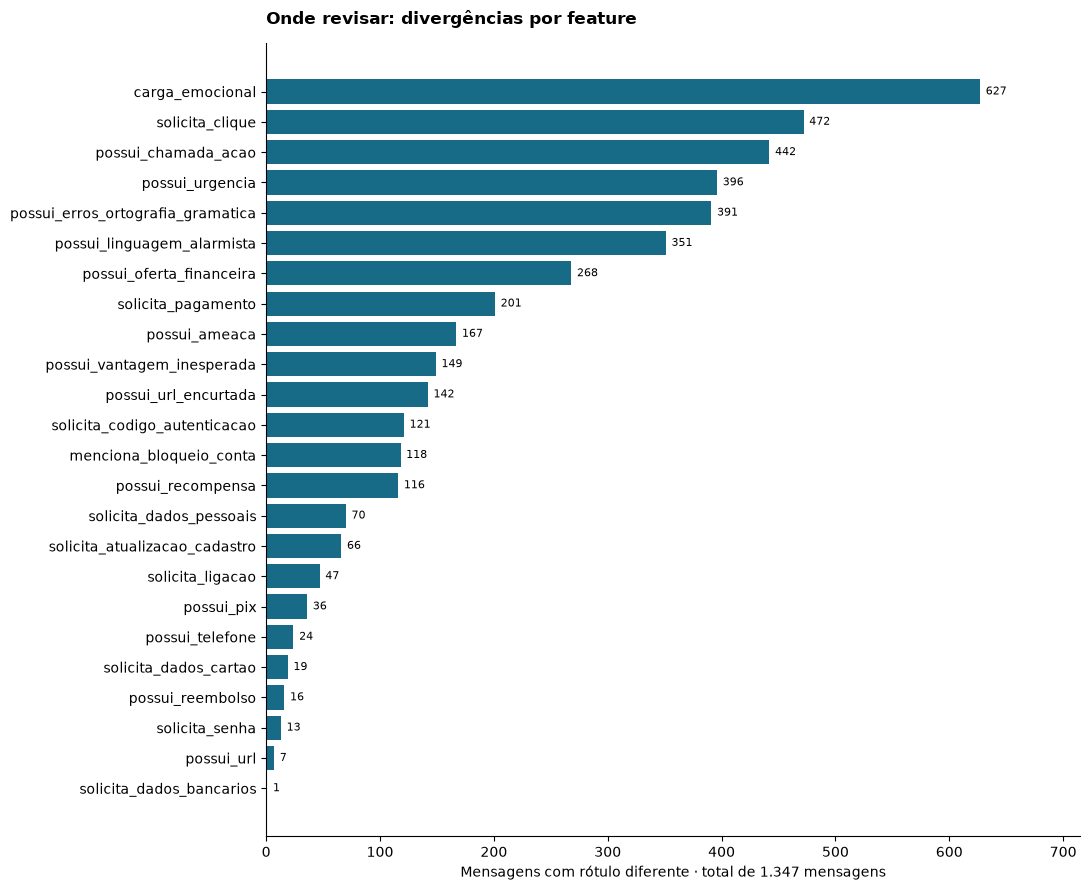

In [19]:
display(metricas[['feature','concordancias','divergencias','concordancia_percentual']].round(2))
graf=metricas.sort_values('divergencias')
fig,ax=plt.subplots(figsize=(11,9))
ax.barh(graf.feature,graf.divergencias,color='#176b87')
for i,v in enumerate(graf.divergencias):ax.text(v+5,i,str(v),va='center',fontsize=8)
ax.set_xlim(0,max(graf.divergencias)*1.14)
ax.set_xlabel('Mensagens com rótulo diferente · total de 1.347 mensagens')
ax.set_title('Onde revisar: divergências por feature',loc='left',fontweight='bold',pad=14)
fig.tight_layout();fig.savefig(SAIDA/'divergencias_por_feature.png',dpi=150,bbox_inches='tight');plt.show()

,baixa,média,alta
carga_emocional,,,
baixa,687,1,0
média,236,5,1
alta,350,39,28


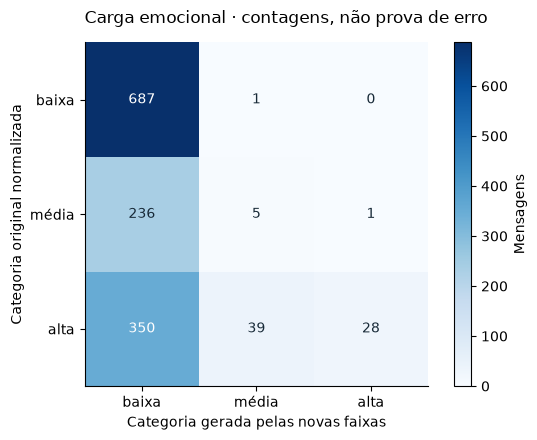

In [20]:
matriz=pd.read_csv(SAIDA/'matriz_carga_emocional.csv',index_col=0)
display(matriz)
fig,ax=plt.subplots(figsize=(6,4.5))
im=ax.imshow(matriz.to_numpy(),cmap='Blues',vmin=0)
ax.set_xticks(range(3),matriz.columns);ax.set_yticks(range(3),matriz.index)
ax.set_xlabel('Categoria gerada pelas novas faixas');ax.set_ylabel('Categoria original normalizada')
for i in range(3):
    for j in range(3):
        v=int(matriz.iloc[i,j]);ax.text(j,i,str(v),ha='center',va='center',color='white' if v>matriz.to_numpy().max()/2 else '#172937')
ax.set_title('Carga emocional · contagens, não prova de erro',loc='left',pad=14)
fig.colorbar(im,ax=ax,label='Mensagens');fig.tight_layout();fig.savefig(SAIDA/'comparacao_emocao.png',dpi=150,bbox_inches='tight');plt.show()

## 6. Verificar o dataset sintético

São **144 mensagens**, seis por feature. Nas 23 features binárias: três casos positivos e três negativos; em carga emocional: dois exemplos de cada categoria operacional. As frases foram criadas para testar pedidos, avisos, negações, identificadores e estruturas que se confundem. As categorias emocionais do gabarito usam a metodologia declarada, não impressão subjetiva.

O arquivo é simples: ID, mensagem, feature-alvo, esperado, página do PDF e justificativa. Cada linha testa apenas uma feature; outras saídas aparecem em `testes_todas_features.csv` como predições **sem gabarito completo**.

Resultados perfeitos nesse conjunto pequeno demonstram consistência com esses casos, não abrangência sobre todos os SMS. As falhas da primeira rodada foram usadas no desenvolvimento e continuam registradas. Novos testes e revisão de divergências reais são necessários para ampliar a cobertura.

In [21]:
por_feature=testes.groupby('feature_alvo',sort=False).agg(casos=('concorda','size'),concordantes=('concorda','sum'))
por_feature['divergentes']=por_feature.casos-por_feature.concordantes
display(por_feature)
display(testes[['id_teste','Mensagem','feature_alvo','esperado','obtido','concorda']].head(12))
falhas=testes[~testes.concorda]
print('Casos sintéticos divergentes:',len(falhas))
if len(falhas):display(falhas)

,casos,concordantes,divergentes
feature_alvo,,,
solicita_senha,6,6,0
solicita_codigo_autenticacao,6,6,0
solicita_dados_bancarios,6,6,0
solicita_dados_pessoais,6,6,0
solicita_dados_cartao,6,6,0
solicita_atualizacao_cadastro,6,6,0
solicita_pagamento,6,6,0
solicita_clique,6,6,0
solicita_ligacao,6,6,0


,id_teste,Mensagem,feature_alvo,esperado,obtido,concorda
0,T01_1,Informe sua senha para concluir a verificação.,solicita_senha,1,1,True
1,T01_2,"Por favor, envie a senha de acesso à conta.",solicita_senha,1,1,True
2,T01_3,Poderia digitar sua senha no formulário?,solicita_senha,1,1,True
3,T01_4,Jamais compartilhe sua senha com terceiros.,solicita_senha,0,0,True
4,T01_5,Sua senha foi alterada com sucesso.,solicita_senha,0,0,True
5,T01_6,"Informe seu CPF, mas não envie sua senha.",solicita_senha,0,0,True
6,T02_1,Envie o token de autenticação para validar a operação.,solicita_codigo_autenticacao,1,1,True
7,T02_2,Informe o código recebido por WhatsApp.,solicita_codigo_autenticacao,1,1,True
8,T02_3,Poderia digitar o código de verificação?,solicita_codigo_autenticacao,1,1,True
9,T02_4,O código de acesso será enviado por SMS.,solicita_codigo_autenticacao,0,0,True


Casos sintéticos divergentes: 0


## 7. Inspecionar o código de qualquer feature

A lista abaixo mostra a definição e o script realmente executado. Use a célula seguinte para mudar `FEATURE` e estudar as outras features. O relatório de revisão cobre as 24, inclusive as mantidas. Regras de intenção compartilham as funções de normalização, solicitação e negação de `regras.py`.

In [22]:
FEATURE='solicita_codigo_autenticacao'
assert FEATURE in motor.NOMES
registro=next(d for d in motor.DEFINICOES if d['nome']==FEATURE)
display(Markdown('**Definição:** '+registro['definicao']+'\n\n**Funcionamento:** '+registro['funcionamento']+'\n\n**Limites:** '+registro['limite']))
display(Code(inspect.getsource(motor.MODULOS[FEATURE]),language='python'))
display(Code(inspect.getsource(motor.preparar),language='python'))

**Definição:** Pedido de código de autenticação, token ou verificação recebido por SMS/WhatsApp.

**Funcionamento:** Acrescenta pedidos de código recebido/enviado por SMS ou WhatsApp; conserva exclusão de códigos de produto e cartão.

**Limites:** Código de produto ou cupom não conta; código de segurança do cartão pertence à feature de cartão.

"""Pedido de código de autenticação; códigos de produto e cupom não contam."""

from ..regras import contem, solicita, trechos


def classificar(sms: str) -> int:
    for trecho in trechos(sms):
        alvo = r"token|otp|codigo (?:de |do |da )?(?:autenticacao|verificacao|confirmacao|sms|whatsapp|acesso|2fa|dois fatores)|codigo (?:recebido|enviado)(?:\s+\w+){0,4}\s+(?:sms|whatsapp)"
        # "Código de segurança" com cartão é dado de cartão, não autenticação.
        if not contem(trecho, r"cartao|cvv|cvc"):
            alvo += r"|codigo de seguranca"
        # Aceita "código de 6 números que recebeu por SMS", como no dicionário.
        alvo += r"|codigo de [46] (?:numeros|digitos)(?:\s+\w+){0,7}\s+(?:sms|whatsapp|autenticacao|verificacao)"
        if solicita(trecho, alvo):
            return 1
    return 0

def preparar(sms):
    # Não deixa domínio/caminho de URL virar intenção; preserva um alvo de clique.
    texto=sms
    for item in reversed(ocorrencias(sms)):
        texto=texto[:item['inicio']]+' endereco_url '+texto[item['fim']:]
    texto=normalizar(texto)
    for imperativo, infinitivo in INFINITIVOS.items():
        texto=re.sub(rf'\b(?:(?:voce )?(?:poderia|pode|deveria)|pedimos para|solicitamos para)\s+{infinitivo}\b',imperativo,texto)
    return re.sub(r'\b(?:solicitamos|pedimos) (?:o )?envio (?:de|do|da)\b','envie',texto)

## 8. Classificar uma mensagem nova

A mesma função atende mensagens isoladas e lotes. Ela retorna os valores, evidências e medida emocional contínua. Não é necessário treinar um modelo no CSV original. Não classifica `possivel_golpe`.

In [23]:
mensagem='Poderia informar seu telefone? Não envie sua senha. Acesse https://example.com.'
resultado=motor.analisar_sms(mensagem)
display(pd.DataFrame([{'feature':n,'valor':v,'metodo':resultado['detalhes'][n]['metodo']} for n,v in resultado['features'].items()]))

,feature,valor,metodo
0,solicita_senha,0,regra contextual explícita / solicita_senha.py
1,solicita_codigo_autenticacao,0,regra contextual explícita / solicita_codigo_autenticacao.py
2,solicita_dados_bancarios,0,regra contextual explícita / solicita_dados_bancarios.py
3,solicita_dados_pessoais,1,regra contextual explícita / solicita_dados_pessoais.py
4,solicita_dados_cartao,0,regra contextual explícita / solicita_dados_cartao.py
5,solicita_atualizacao_cadastro,0,regra contextual explícita / solicita_atualizacao_cadastro.py
6,solicita_pagamento,0,regra contextual explícita / solicita_pagamento.py
7,solicita_clique,1,regra contextual explícita / solicita_clique.py
8,solicita_ligacao,0,regra contextual explícita / solicita_ligacao.py
9,menciona_bloqueio_conta,0,regra contextual explícita / menciona_bloqueio_conta.py


## 9. Integridade e interpretação final

Esta versão mantém os scripts e dados anteriores intactos. A checagem abaixo confirma os hashes capturados antes da criação desta pasta. Os SMS sintéticos também são conferidos para garantir que não foram acrescentados ao CSV original.

A revisão humana deve manter aberta a possibilidade de erro em ambos os lados. O novo extrator prioriza critérios explícitos e evidência auditável; ele ainda pode perder formulações não previstas. A decisão registrada é sua, e o arquivo original não é alterado por este notebook.

In [24]:
preservados=json.loads((PASTA/'preservacao_antes.json').read_text())
# Bibliotecas instaladas na .venv mudam legitimamente com pip.
# O manifesto original permanece intacto; dados e código continuam protegidos.
verificados={nome:h for nome,h in preservados.items() if '.venv' not in Path(nome).parts}
ausentes=[nome for nome in verificados if not (PROJETO/nome).is_file()]
alterados=[nome for nome,h in verificados.items()
           if (PROJETO/nome).is_file() and digest(PROJETO/nome)!=h]
# Histórico de outras versões é informativo, não uma dependência da análise.
if ausentes or alterados:
    print(f'AVISO: histórico com {len(ausentes)} arquivos ausentes e '
          f'{len(alterados)} alterados. Isso não indica erro de classificação.')
    print('Exemplos:', (ausentes+alterados)[:5])
# A integridade da fonte continua obrigatória, inclusive em relação ao manifesto.
chave_fonte=fonte.relative_to(PROJETO).as_posix()
if chave_fonte in preservados:
    assert digest(fonte)==preservados[chave_fonte], 'Dataset original difere da referência histórica.'
orig=pd.read_csv(fonte,dtype=str,keep_default_na=False)
sint=pd.read_csv(PASTA/'testes/sms_teste.csv',dtype=str,keep_default_na=False)
assert not set(orig.Mensagem)&set(sint.Mensagem)
assert len(orig)==resumo['mensagens_originais']
assert digest(fonte)==hash_fonte
print(f'Preservados {len(verificados)-len(ausentes)-len(alterados)} arquivos anteriores do projeto; '
      f'{len(preservados)-len(verificados)} arquivos da .venv fora da verificação. '
      'Dataset original conferido; testes continuam separados.')
display(Markdown(f"Foram encontradas **{resumo['divergencias']:,} diferenças** em **{resumo['mensagens_com_divergencia']:,} mensagens**. A concordância global foi **{resumo['concordancia_percentual']:.2f}%** nas 24 features. Os testes sintéticos tiveram **{resumo['testes_alvo_concordantes']}/{resumo['sms_sinteticos']}** concordâncias nas features-alvo. Use os resultados detalhados para revisar, sem interpretar essas métricas como certificação do dataset."))

AVISO: histórico com 1536 arquivos ausentes e 0 alterados. Isso não indica erro de classificação.
Exemplos: ['entrega_sem_bibliotecas.zip', 'DATASET - Dataset_limpo_sem_atributos_sem_bibliotecacsv', 'notebook_features/comparacao_features_sms.ipynb', 'notebook_features/requirements.txt', 'notebook_features/comparacao_features_sms.html']
Preservados 145 arquivos anteriores do projeto; 20403 arquivos da .venv fora da verificação. Dataset original conferido; testes continuam separados.


Foram encontradas **4,260 diferenças** em **1,137 mensagens**. A concordância global foi **86.82%** nas 24 features. Os testes sintéticos tiveram **144/144** concordâncias nas features-alvo. Use os resultados detalhados para revisar, sem interpretar essas métricas como certificação do dataset.